### LOADING CLEANED DATASET

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import StandardScaler, LabelEncoder

import json

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0})

df = pd.read_csv('../data/processed/cleaned_realdonaldtrump.csv')
content_series = df['content'].fillna("")
print(f"Dataset loaded successfully! Shape: {df.shape}")

Dataset loaded successfully! Shape: (43352, 14)


### NLP FEATURES ENGINEERING

In [15]:
# NOTE: We intentionally use the raw 'content' column here, not 'processed_content'.
# During preprocessing, URLs, mentions (@user), and special characters (#) are stripped
# to produce clean text for NLP vectorization. Therefore, structural features like
# hashtag/mention counts MUST be extracted from the original text before cleaning.
df['exclamation_count'] = content_series.str.count('!')
df['question_count'] = content_series.str.count(r'\?')

df['capslock_words_count'] = content_series.str.findall(r'\b[A-Z]{2,}\b').str.len().fillna(0).astype(int)
df['word_count'] = content_series.str.split().str.len().fillna(0).astype(int)
df['char_count'] = content_series.str.len()
df['hashtag_count'] = content_series.str.count('#')
df['mention_count'] = content_series.str.count('@')

# Shouting index: ratio of capital letters to total characters
df['shouting_index'] = content_series.str.findall(r'[A-Z]').str.len() / (df['char_count'] + 1)

def calculate_ttr(text: str) -> float:
    """
    Calculate Type-Token Ratio (TTR) for a given text. TTR = (Number of Unique Words) / (Total Number of Words).
    """
    tokens = str(text).split()
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

df['lexical_diversity_ttr'] = df['cleaned_content'].apply(calculate_ttr)
df['has_hashtag'] = df['has_hashtag'].fillna(0).astype(int)
df['has_mention'] = df['has_mention'].fillna(0).astype(int)

print("Basic features extracted!")

Basic features extracted!


### NUMERIC TOKEN ANALYSIS

Tweets with any number:   13,118 (30.3%)
Tweets with year mention: 1,371 (3.2%)
Tweets with large number: 109 (0.3%)


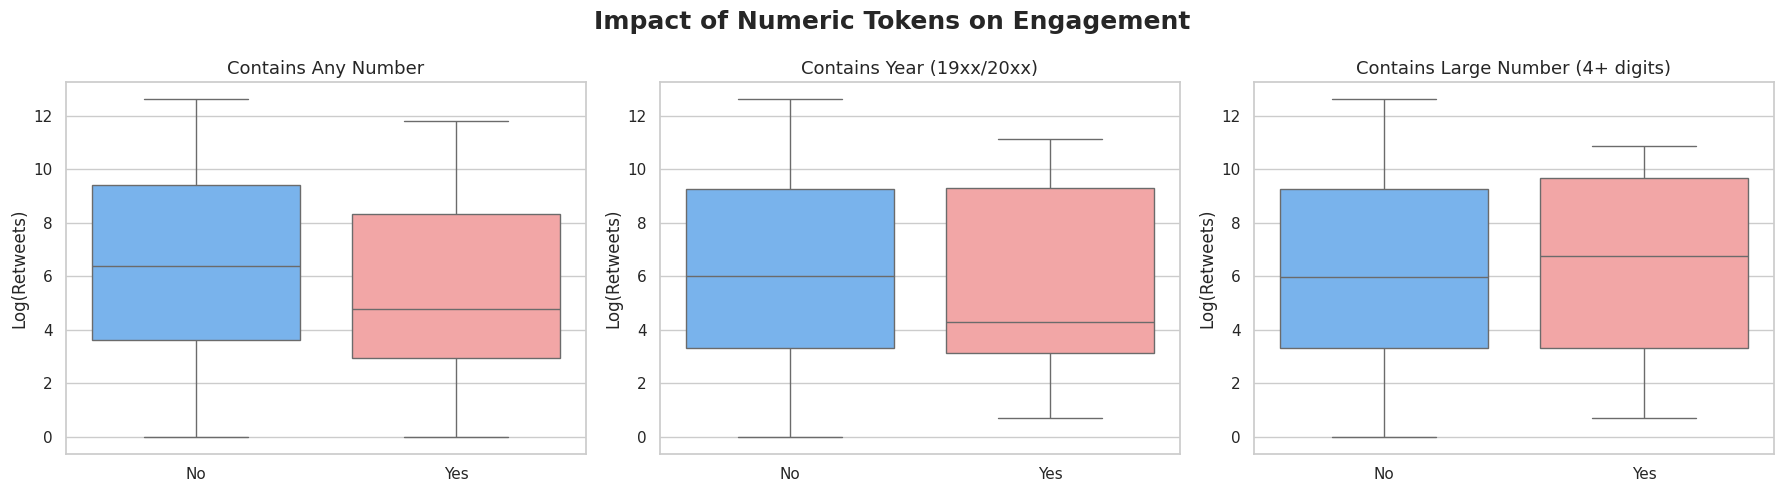

Numeric token features extracted!


In [16]:
# Digits were preserved during cleaning (regex [^a-z0-9\s]) to retain contextual
# numbers like years (2020), quantities (100), and percentages.
# Here we analyze whether tweets containing numbers show different engagement.

df['has_number'] = df['cleaned_content'].str.contains(r'\d+', regex=True).astype(int)
df['number_token_count'] = df['cleaned_content'].str.findall(r'\b\d+\b').str.len().fillna(0).astype(int)
df['has_year_mention'] = df['cleaned_content'].str.contains(r'\b(?:19|20)\d{2}\b', regex=True).astype(int)
df['has_large_number'] = df['cleaned_content'].str.contains(r'\b(?!(?:19|20)\d{2})\d{4,}\b', regex=True).astype(int)

print(f"Tweets with any number:   {df['has_number'].sum():,} ({df['has_number'].mean()*100:.1f}%)")
print(f"Tweets with year mention: {df['has_year_mention'].sum():,} ({df['has_year_mention'].mean()*100:.1f}%)")
print(f"Tweets with large number: {df['has_large_number'].sum():,} ({df['has_large_number'].mean()*100:.1f}%)")

# Visualization: engagement by numeric content
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impact of Numeric Tokens on Engagement', fontsize=18, fontweight='bold')

log_rt = np.log1p(df['retweets'])

for ax, col, label in zip(axes,
                           ['has_number', 'has_year_mention', 'has_large_number'],
                           ['Contains Any Number', 'Contains Year (19xx/20xx)', 'Contains Large Number (4+ digits)']):
    sns.boxplot(x=df[col].map({0: 'No', 1: 'Yes'}), y=log_rt,
                palette=['#66b3ff', '#ff9999'], ax=ax, hue=df[col].map({0: 'No', 1: 'Yes'}), legend=False)
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Log(Retweets)')

plt.tight_layout()
plt.show()

print("Numeric token features extracted!")

### SENTIMENT ANALYSIS - Valence Aware Dictionary and sEntiment Reasoner

In [17]:
import re

nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

def clean_for_vader(text: str) -> str:
    """
    Preprocess text for VADER sentiment analysis by removing URLs, mentions, and extra whitespace.
    VADER is designed to handle informal text, so we keep punctuation and capitalization.
    """
    if not isinstance(text, str):
        return ""

    text = re.sub(r'http\S+|www\.\S+|pic\.twitter\.com/\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_vader_scores(text: str) -> dict:
    """
    Calculate VADER sentiment scores for a given text. Returns a dictionary with 'neg', 'neu', 'pos', and 'compound' scores.
    If the input is not a valid string, returns neutral scores.
    """
    if not isinstance(text, str) or text.strip() == "":
        return {"neg": 0.0, "neu": 1.0, "pos": 0.0, "compound": 0.0}
    return sia.polarity_scores(text)

sentiment_df = df["content"].apply(clean_for_vader).apply(get_vader_scores).apply(pd.Series)
sentiment_df = sentiment_df.add_prefix('sent_vader_')
df = pd.concat([df, sentiment_df], axis=1)

def categorize_sentiment(compound: float) -> str:
    """
    Categorize sentiment based on VADER compound score.
    """
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sent_vader_compound'].apply(categorize_sentiment)
print("Sentiment analysis complete!")

Sentiment analysis complete!


### TEXT REPRESENTATION: CountVectorizer + TF-IDF (Term Frequency - Inverse Document Frequency) + LDA (Latent Dirichlet Allocation)

In [18]:
# We produce a few representations so the modeling notebook (04) can
# benchmark them and select the best-performing one.

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

MAX_FEATURES = 10000
N_TOPICS = 5

# Full corpus, aligned with full df
corpus = df["processed_content"].fillna("")

# CountVectorizer: raw term counts, include unigrams and bigrams
count_vec = CountVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

X_count = count_vec.fit_transform(corpus)
print(f"CountVectorizer matrix shape: {X_count.shape}")

# TF-IDF: weighted word/bigram representation
tfidf_vec = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

X_tfidf = tfidf_vec.fit_transform(corpus)
print(f"TF-IDF matrix shape: {X_tfidf.shape}")

# LDA Topic Modeling fitted on raw count features
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42
)

X_topics = lda.fit_transform(X_count)
print(f"LDA topic matrix shape: {X_topics.shape}")

for i in range(N_TOPICS):
    df[f"topic_lda_{i+1}"] = X_topics[:, i]

# Print topic keywords
feature_names = count_vec.get_feature_names_out()

for topic_idx, topic_weights in enumerate(lda.components_):
    top_indices = topic_weights.argsort()[-15:][::-1]
    top_terms = [feature_names[i] for i in top_indices]

    print(f"Topic {topic_idx + 1}:")
    print(", ".join(top_terms))
    print()

print("Text representation complete!")

CountVectorizer matrix shape: (43352, 10000)
TF-IDF matrix shape: (43352, 10000)
LDA topic matrix shape: (43352, 5)
Topic 1:
our, great, we, will, country, job, border, our country, state, china, not, american, year, they, people

Topic 2:
will, news, we, my, great, fake, big, they, fake news, medium, time, me, people, much, new

Topic 3:
you, realdonaldtrump, thank, thank you, great, your, my, president, run, trump2016, we, thanks, need, love, mr

Topic 4:
he, they, not, no, his, can, president, people, would, me, obama, him, democrat, like, never

Topic 5:
trump, realdonaldtrump, donald, great, thanks, donald trump, via, new, your, best, make, america, think, golf, course

Text representation complete!


### VISUALIZATION: DISTRIBUTIONS OF ENGINEERED TEXT FEATURES

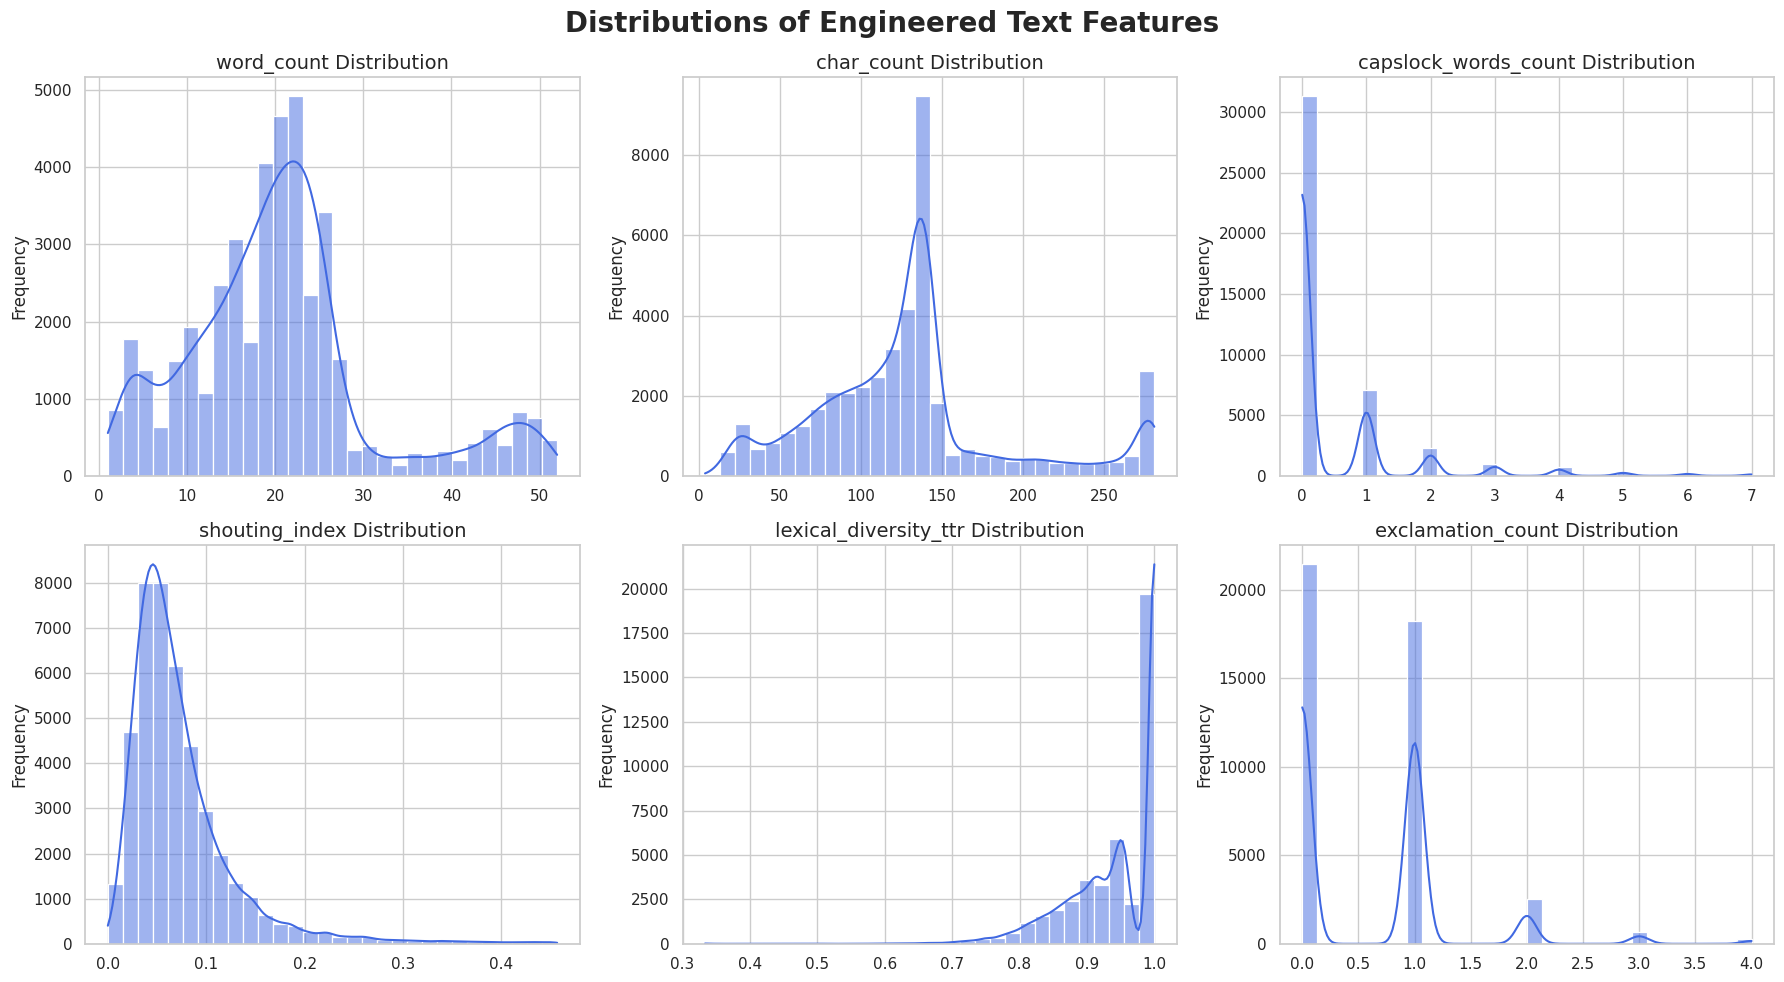

In [19]:
features_to_plot = ['word_count', 'char_count', 'capslock_words_count', 'shouting_index', 'lexical_diversity_ttr', 'exclamation_count']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributions of Engineered Text Features', fontsize=20, fontweight='bold')

for i, feature in enumerate(features_to_plot):
    row, col = divmod(i, 3)
    max_val = df[feature].quantile(0.99)
    filtered_data = df[df[feature] <= max_val][feature]

    sns.histplot(filtered_data, bins=30, ax=axes[row, col], color='royalblue', kde=True)
    axes[row, col].set_title(f'{feature} Distribution', fontsize=14)
    axes[row, col].set_xlabel('')
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### VISUALIZATION: SENTIMENT AND ENGAGEMENT

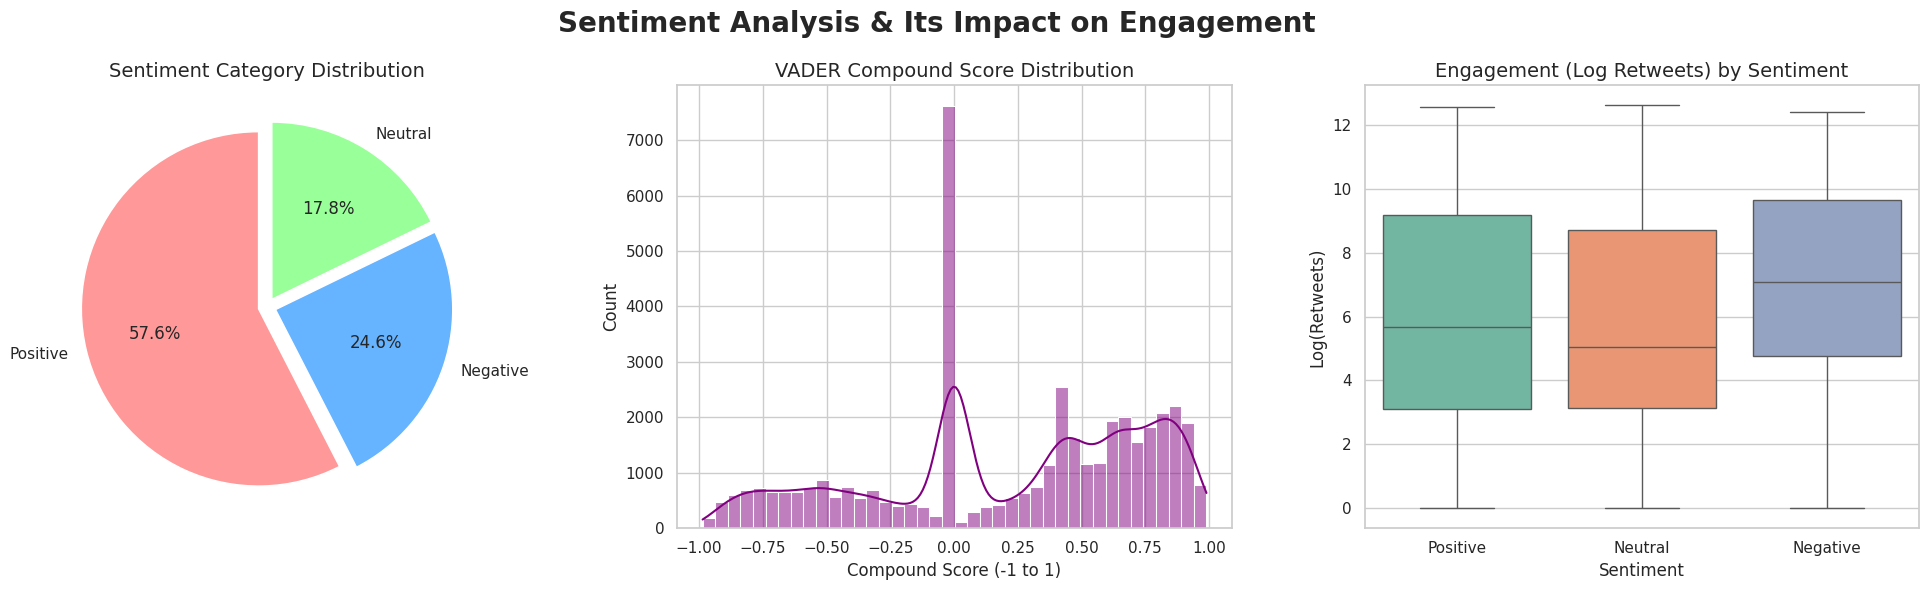

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Sentiment Analysis & Its Impact on Engagement', fontsize=20, fontweight='bold')

sentiment_counts = df['sentiment_category'].value_counts()
axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=90, explode=(0.05, 0.05, 0.05))
axes[0].set_title('Sentiment Category Distribution', fontsize=14)

sns.histplot(df['sent_vader_compound'], bins=40, color='purple', kde=True, ax=axes[1])
axes[1].set_title('VADER Compound Score Distribution', fontsize=14)
axes[1].set_xlabel('Compound Score (-1 to 1)')

df['log_retweets'] = np.log1p(df['retweets'])

sns.boxplot(x='sentiment_category', y='log_retweets', data=df, palette='Set2', ax=axes[2], hue='sentiment_category', legend=False)

axes[2].set_title('Engagement (Log Retweets) by Sentiment', fontsize=14)
axes[2].set_ylabel('Log(Retweets)')
axes[2].set_xlabel('Sentiment')

plt.tight_layout()
plt.show()

### VISUALIZATION: LDA TOPIC MODELING

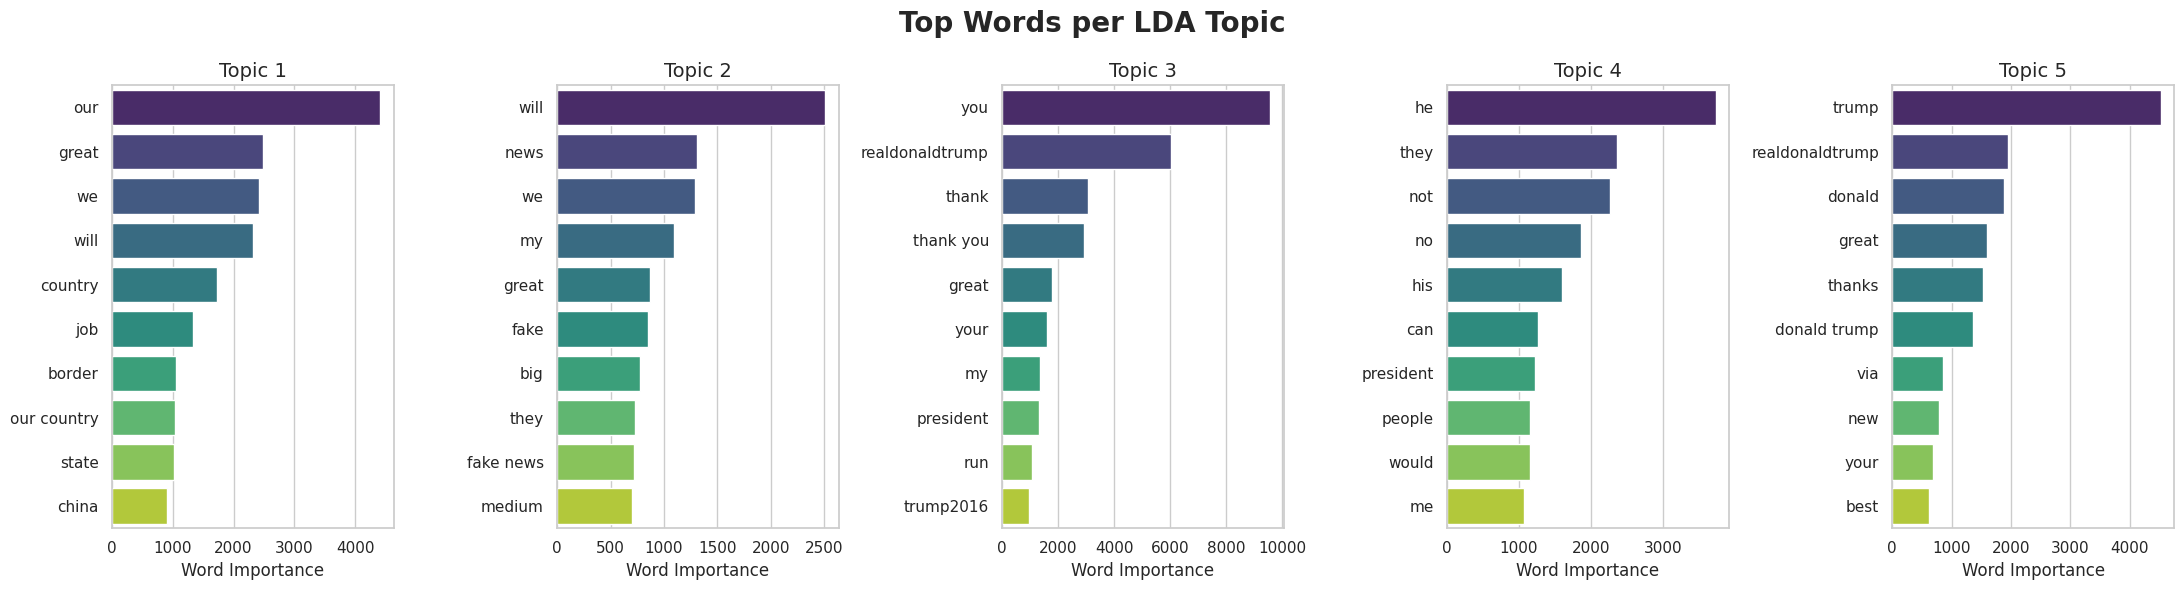

In [21]:
lda_feature_names = tfidf_vec.get_feature_names_out()

fig, axes = plt.subplots(1, N_TOPICS, figsize=(22, 6), sharey=False)
fig.suptitle('Top Words per LDA Topic', fontsize=20, fontweight='bold')

for topic_idx, topic in enumerate(lda.components_):
    top_features_ind = topic.argsort()[:-11:-1]
    top_features = [lda_feature_names[i] for i in top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]
    sns.barplot(x=weights, y=top_features, ax=ax, palette='viridis', hue=top_features, legend=False)
    ax.set_title(f'Topic {topic_idx + 1}', fontsize=14)
    ax.set_xlabel('Word Importance')

plt.tight_layout()
plt.show()

### VISUALIZATION: CORRELATION HEATMAP

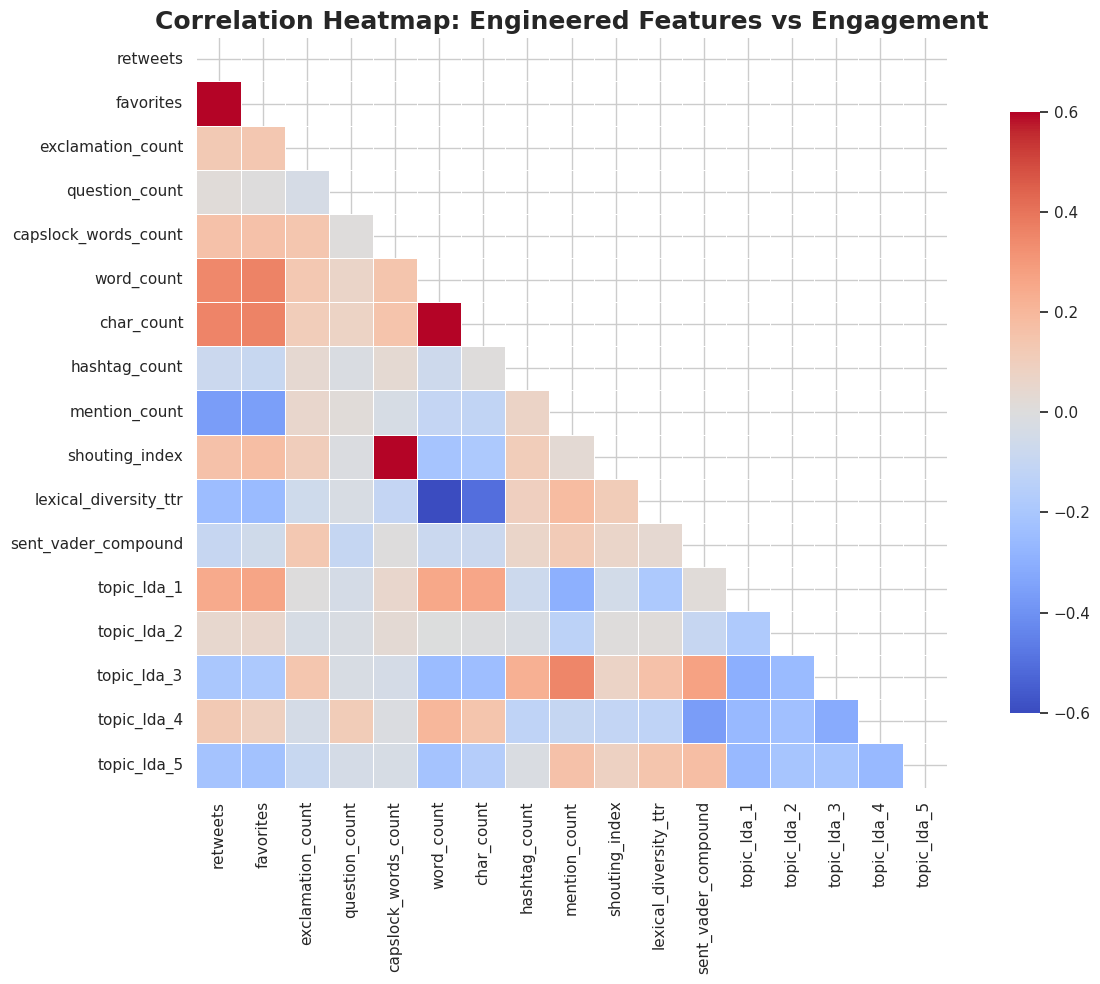

In [22]:
numeric_cols = [
    'retweets', 'favorites', 'exclamation_count', 'question_count', 'capslock_words_count',
    'word_count', 'char_count', 'hashtag_count', 'mention_count',
    'shouting_index', 'lexical_diversity_ttr', 'sent_vader_compound',
    'topic_lda_1', 'topic_lda_2', 'topic_lda_3', 'topic_lda_4', 'topic_lda_5'
]

plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmax=0.6, vmin=-0.6, center=0, square=True, linewidths=.5, annot=False, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap: Engineered Features vs Engagement', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### EXPORT FEATURES FOR MODELING

In [24]:
# Produces two feature matrices for notebook 04 to benchmark:
#   - X_tfidf_features.npz  (TF-IDF + normalized numeric)
#   - X_count_features.npz  (CountVectorizer + normalized numeric)
# Plus metadata needed for SHAP and reproducibility.

numerical_features = [
    'exclamation_count', 'question_count', 'capslock_words_count',
    'word_count', 'char_count', 'hashtag_count', 'mention_count',
    'has_hashtag', 'has_mention',
    'has_number', 'number_token_count', 'has_year_mention', 'has_large_number',
    'shouting_index', 'lexical_diversity_ttr',
    'sent_vader_neg', 'sent_vader_pos', 'sent_vader_compound',
    'topic_lda_1', 'topic_lda_2', 'topic_lda_3', 'topic_lda_4', 'topic_lda_5'
]

scaler = StandardScaler()
X_numeric_scaled = sp.csr_matrix(scaler.fit_transform(df[numerical_features].values))

X_tfidf_final = sp.hstack([X_tfidf, X_numeric_scaled])
X_count_final = sp.hstack([X_count, X_numeric_scaled])

print(f"TF-IDF feature matrix shape:  {X_tfidf_final.shape}")
print(f"Count  feature matrix shape:  {X_count_final.shape}")

# Target variable (y)
le = LabelEncoder()
y = le.fit_transform(df['engagement_level'])   # Encodes engagement_level classes as integers; mapping is printed below.
print(f"\nTarget variable: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Feature names for SHAP
# order must match column order in X_*_final matrices
tfidf_feature_names = tfidf_vec.get_feature_names_out().tolist()
count_feature_names = count_vec.get_feature_names_out().tolist()

feature_names_tfidf = tfidf_feature_names + numerical_features
feature_names_count = count_feature_names + numerical_features

# log_retweets is saved in df_with_features.csv for optional regression experiments.
# It is intentionally NOT included in the feature matrix (would be target leakage).
df['log_retweets'] = np.log1p(df['retweets'])

sp.save_npz('../data/processed/X_tfidf_features.npz', X_tfidf_final)
sp.save_npz('../data/processed/X_count_features.npz', X_count_final)
np.save('../data/processed/y_labels.npy', y)
np.save('../data/processed/label_classes.npy', le.classes_)

with open('../data/processed/feature_names_tfidf.json', 'w') as f:
    json.dump(feature_names_tfidf, f)
with open('../data/processed/feature_names_count.json', 'w') as f:
    json.dump(feature_names_count, f)

df.to_csv('../data/processed/df_with_features.csv', index=False)

print("\nSaved X_tfidf_features.npz")
print("Saved X_count_features.npz")
print("Saved y_labels.npy + label_classes.npy")
print("Saved feature_names_tfidf.json + feature_names_count.json")
print("Saved df_with_features.csv")

TF-IDF feature matrix shape:  (43352, 10023)
Count  feature matrix shape:  (43352, 10023)

Target variable: {'High': 0, 'Low': 1, 'Medium': 2}

Saved X_tfidf_features.npz
Saved X_count_features.npz
Saved y_labels.npy + label_classes.npy
Saved feature_names_tfidf.json + feature_names_count.json
Saved df_with_features.csv
